# 05 — Random Forest Training (Issue #12)

Trains a Random Forest classifier for network threat classification on the NSL-KDD dataset.

**Pipeline:** load raw data → clean → encode categoricals/target → scale numeric features → train Random Forest → evaluate → save model artifact.

Target: 5-class `attack_category` — `Normal`, `DoS`, `Probe`, `R2L`, `U2R`.

In [1]:
# Make sure the notebook can import the ml package regardless of the
# working directory it's launched from.
import os
import sys

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from ml.preprocessing.preprocessing_pipeline import run_preprocessing_pipeline
from ml.models.random_forest_model import RandomForestModel, DEFAULT_HYPERPARAMS

sns.set_theme(style="whitegrid")
print("Imports OK")

Imports OK


## 1. Load & preprocess data

Runs the full preprocessing pipeline (load → clean → encode → scale) and persists the fitted encoders/scaler under `ml/artifacts/preprocessor.joblib` for reuse at inference time.

In [2]:
data = run_preprocessing_pipeline()

X_train, X_test = data["X_train"], data["X_test"]
y_train, y_test = data["y_train"], data["y_test"]
class_names = data["class_names"]

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("Classes:", class_names)

X_train: (125973, 41)
X_test : (22544, 41)
Classes: ['DoS', 'Normal', 'Probe', 'R2L', 'U2R']


In [3]:
# Class balance in the training set
train_counts = pd.Series(y_train).value_counts().sort_index()
train_counts.index = [class_names[i] for i in train_counts.index]
train_counts

DoS       45927
Normal    67343
Probe     11656
R2L         995
U2R          52
Name: count, dtype: int64

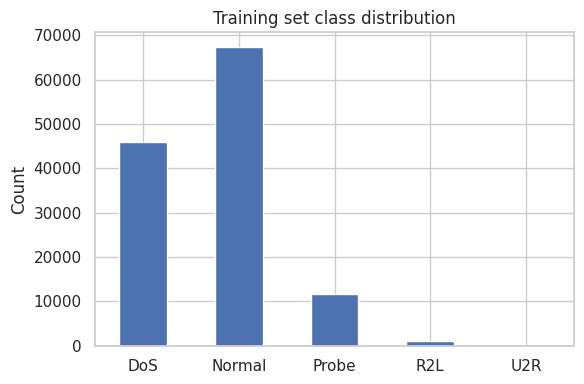

In [4]:
train_counts.plot(kind="bar", color="#4C72B0", figsize=(6,4))
plt.title("Training set class distribution")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 2. Configure hyperparameters

Default hyperparameters (documented in `ml/models/random_forest_model.py`):

In [5]:
for k, v in DEFAULT_HYPERPARAMS.items():
    print(f"{k:20s}: {v}")

n_estimators        : 200
max_depth           : None
min_samples_split   : 2
min_samples_leaf    : 1
max_features        : sqrt
class_weight        : balanced
n_jobs              : -1
random_state        : 42


## 3. Train the Random Forest model

In [6]:
rf = RandomForestModel()  # uses DEFAULT_HYPERPARAMS; pass a dict to override
train_info = rf.train(
    X_train, y_train,
    feature_names=data["feature_names"],
    class_names=class_names,
)
print(f"Training time: {train_info['train_time_seconds']}s")

Training time: 14.35s


## 4. Generate predictions & evaluate

In [7]:
metrics, y_pred = rf.evaluate(X_test, y_test)

print(f"Accuracy      : {metrics['accuracy']:.4f}")
print(f"Precision(mac): {metrics['precision_macro']:.4f}")
print(f"Recall (mac)  : {metrics['recall_macro']:.4f}")
print(f"F1 (mac)      : {metrics['f1_macro']:.4f}\n")
print(metrics["classification_report"])

Accuracy      : 0.7368
Precision(mac): 0.7113
Recall (mac)  : 0.4730
F1 (mac)      : 0.4765

              precision    recall  f1-score   support

         DoS       0.96      0.77      0.85      7460
      Normal       0.63      0.97      0.77      9711
       Probe       0.86      0.59      0.70      2421
         R2L       0.60      0.00      0.00      2885
         U2R       0.50      0.03      0.06        67

    accuracy                           0.74     22544
   macro avg       0.71      0.47      0.48     22544
weighted avg       0.76      0.74      0.69     22544



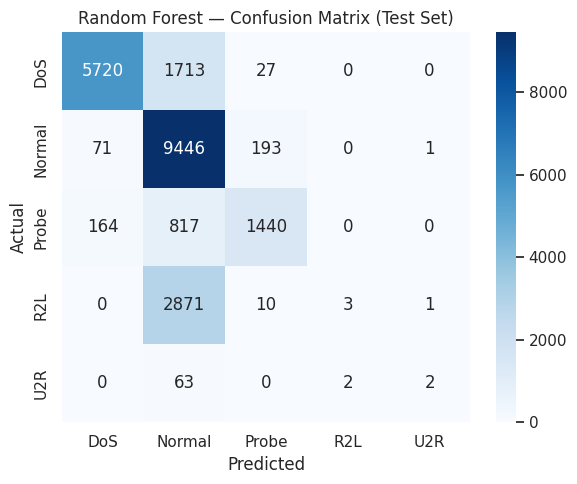

In [8]:
cm = np.array(metrics["confusion_matrix"])
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest — Confusion Matrix (Test Set)")
plt.tight_layout()
plt.show()

## 5. Feature importance

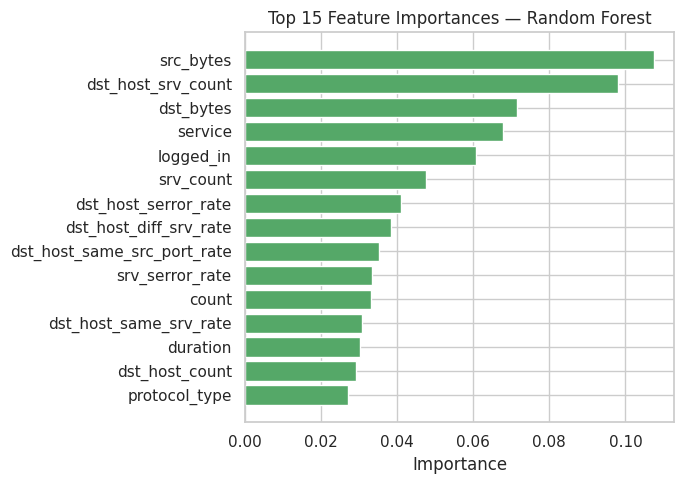

In [9]:
importances = rf.feature_importances()[:15]
names, values = zip(*importances)

plt.figure(figsize=(7,5))
plt.barh(names[::-1], values[::-1], color="#55A868")
plt.title("Top 15 Feature Importances — Random Forest")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

## 6. Save the trained model

Saved under `ml/artifacts/random_forest_model.joblib`, alongside the preprocessing artifacts saved in step 1.

In [10]:
saved_path = rf.save()
print("Model saved to:", saved_path)

Model saved to: /home/claude/NTCF-minor-project-/NTCF-minor-project-/ml/artifacts/random_forest_model.joblib


## 7. Reload check — verify the saved model can be loaded for inference

In [11]:
reloaded = RandomForestModel.load(saved_path)
sample_preds = reloaded.predict(X_test.iloc[:10])
sample_true = y_test[:10]

pd.DataFrame({
    "predicted": [class_names[i] for i in sample_preds],
    "actual": [class_names[i] for i in sample_true],
})

,predicted,actual
0,DoS,DoS
1,DoS,DoS
2,Normal,Normal
3,Probe,Probe
4,Normal,Probe
5,Normal,Normal
6,Normal,Normal
7,Normal,R2L
8,Normal,Normal
9,Normal,R2L


## Model configuration summary

- **Algorithm**: scikit-learn `RandomForestClassifier`
- **Target**: 5-class attack category (`Normal`, `DoS`, `Probe`, `R2L`, `U2R`), derived from the raw NSL-KDD text labels via `ml/config/columns.py::ATTACK_CATEGORY_MAP`
- **Features**: 41 NSL-KDD flow features — 3 categorical (`protocol_type`, `service`, `flag`) label-encoded, 38 numeric features standard-scaled
- **Key hyperparameters**: see section 2 above — notably `class_weight="balanced"` to address the strong class imbalance (U2R/R2L are rare vs Normal/DoS)
- **Artifacts saved**:
  - `ml/artifacts/preprocessor.joblib` — fitted encoders + scaler
  - `ml/artifacts/random_forest_model.joblib` — trained model + metadata
- **Acceptance criteria met**: model trains successfully, predictions are generated, model is saved and reloadable, notebook executes end-to-end.